In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake (1).csv
Saving True.csv to True (1).csv


In [9]:
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

In [10]:
fake['text'][0]

'Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t ev

In [11]:
true.shape

(21417, 4)

In [12]:
fake.shape

(23481, 4)

In [13]:
fake['label'] = 'fake'

In [14]:
true['label'] = 'true'

In [15]:
data = pd.concat([true, fake], ignore_index= True)

In [16]:
data['label'].unique()

array(['true', 'fake'], dtype=object)

In [17]:
data.shape

(44898, 5)

In [18]:
data.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [19]:
data.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [20]:
data['content'] = data['text'] +' '+ data['title']

In [21]:
data.head()

,title,text,subject,date,label,content
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",true,WASHINGTON (Reuters) - The head of a conservat...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",true,WASHINGTON (Reuters) - Transgender people will...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",true,WASHINGTON (Reuters) - The special counsel inv...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",true,WASHINGTON (Reuters) - Trump campaign adviser ...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",true,SEATTLE/WASHINGTON (Reuters) - President Donal...


In [22]:
data['content'] = data['content'].str.lower()

In [23]:
data.head()

,title,text,subject,date,label,content
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",true,washington (reuters) - the head of a conservat...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",true,washington (reuters) - transgender people will...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",true,washington (reuters) - the special counsel inv...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",true,washington (reuters) - trump campaign adviser ...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",true,seattle/washington (reuters) - president donal...


In [24]:
import string
for char in string.punctuation:
    data['content'] = data['content'].str.replace(char, ' ')

In [25]:
data['content'] = data['content'].str.replace('“', '')
data['content'] = data['content'].str.replace('”', '')
data['content'] = data['content'].str.replace("’", '')
data['content'] = data['content'].str.replace("‘", '')
data['content'] = data['content'].str.replace("'", '')
data['content'] = data['content'].str.replace(",", '')

In [26]:
!pip install nltk

In [27]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [28]:
stopwords = set(stopwords.words('english'))


data['content'] = data['content'].apply( lambda row : ' '.join([word for word in row.split() if word not in stopwords]))

In [29]:
data['content']

,content
0,washington reuters head conservative republica...
1,washington reuters transgender people allowed ...
2,washington reuters special counsel investigati...
3,washington reuters trump campaign adviser geor...
4,seattle washington reuters president donald tr...
...,...
44893,21st century wire says 21wire reported earlier...
44894,21st century wire says familiar theme whenever...
44895,patrick henningsen 21st century wireremember o...
44896,21st century wire says al jazeera america go h...


In [30]:
data['content'] = data['content'].astype(str)

In [31]:
num_list =['0','1','2','3','4','5','6','7','8','9']

for x in num_list:
    data['content'] = data['content'].str.replace(x, ' ')

In [32]:
from collections import Counter

In [33]:
fake_words = ' '.join(data[data['label'] == 'fake']['content'])
fake_counts =  Counter(fake_words.split())
fake_counts.most_common(30)

[('trump', 87607),
 ('said', 33954),
 ('president', 28915),
 ('people', 27077),
 ('one', 25194),
 ('would', 23818),
 ('obama', 20686),
 ('clinton', 20197),
 ('donald', 18630),
 ('like', 18509),
 ('video', 16807),
 ('hillary', 16005),
 ('news', 15551),
 ('also', 15446),
 ('us', 15444),
 ('new', 15313),
 ('even', 14245),
 ('time', 14172),
 ('white', 14053),
 ('state', 13904),
 ('via', 12852),
 ('media', 12405),
 ('twitter', 12164),
 ('america', 11779),
 ('american', 11759),
 ('house', 11651),
 ('campaign', 11558),
 ('get', 11210),
 ('right', 11179),
 ('first', 10949)]

In [34]:
true_words = ' '.join(data[data['label'] == 'true']['content'])
true_counts =  Counter(fake_words.split())
true_counts.most_common(30)

[('trump', 87607),
 ('said', 33954),
 ('president', 28915),
 ('people', 27077),
 ('one', 25194),
 ('would', 23818),
 ('obama', 20686),
 ('clinton', 20197),
 ('donald', 18630),
 ('like', 18509),
 ('video', 16807),
 ('hillary', 16005),
 ('news', 15551),
 ('also', 15446),
 ('us', 15444),
 ('new', 15313),
 ('even', 14245),
 ('time', 14172),
 ('white', 14053),
 ('state', 13904),
 ('via', 12852),
 ('media', 12405),
 ('twitter', 12164),
 ('america', 11779),
 ('american', 11759),
 ('house', 11651),
 ('campaign', 11558),
 ('get', 11210),
 ('right', 11179),
 ('first', 10949)]

In [35]:
data

,title,text,subject,date,label,content
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",true,washington reuters head conservative republica...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",true,washington reuters transgender people allowed ...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",true,washington reuters special counsel investigati...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",true,washington reuters trump campaign adviser geor...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",true,seattle washington reuters president donald tr...
...,...,...,...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",fake,st century wire says wire reported earlier...
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",fake,st century wire says familiar theme whenever...
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",fake,patrick henningsen st century wireremember o...
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",fake,st century wire says al jazeera america go h...


In [36]:

data['content_length'] = data['content'].apply(lambda x: len(x.split()))

In [37]:
data['content_length']

,content_length
0,451
1,386
2,271
3,238
4,502
...,...
44893,328
44894,179
44895,2385
44896,284


In [38]:
data.head()

,title,text,subject,date,label,content,content_length
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",true,washington reuters head conservative republica...,451
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",true,washington reuters transgender people allowed ...,386
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",true,washington reuters special counsel investigati...,271
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",true,washington reuters trump campaign adviser geor...,238
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",true,seattle washington reuters president donald tr...,502


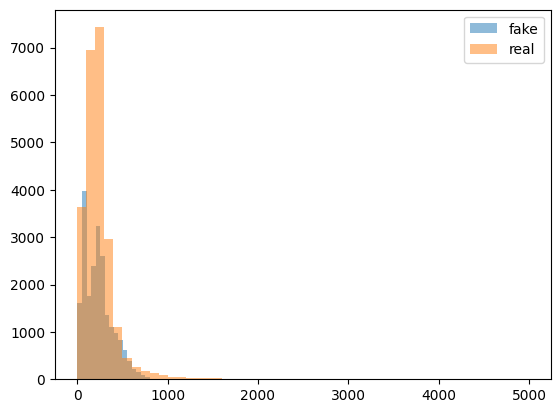

In [39]:
import matplotlib.pyplot as plt
%matplotlib inline
x = data[data['label'] == 'true']['content_length']  # fake
y = data[data['label'] == 'fake']['content_length']  # real

plt.hist(x, bins=50, alpha=0.5, label='fake')
plt.hist(y, bins=50, alpha=0.5, label='real')
plt.legend()
plt.show()

In [40]:
data['label'].unique()

array(['true', 'fake'], dtype=object)

In [41]:
x.describe()
y.describe()

,content_length
count,23481.000000
mean,249.607470
std,238.332565
min,3.000000
25%,147.000000
50%,213.000000
75%,294.000000
max,4989.000000


In [42]:
subject_count = data['subject'].value_counts()
subject_count

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


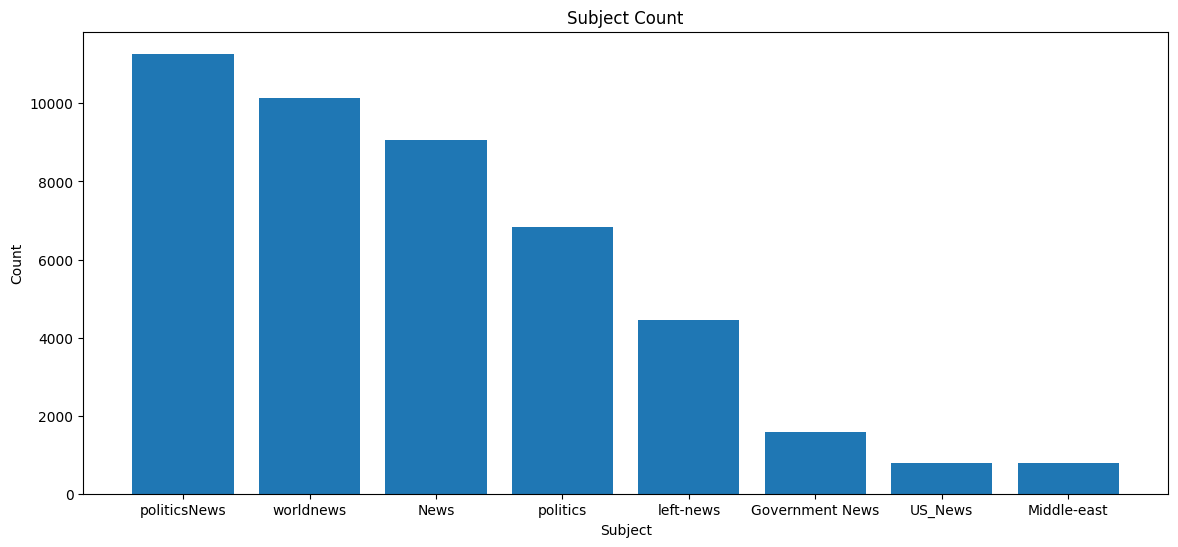

In [43]:
plt.figure(figsize=(14, 6))
x = subject_count.index
y = subject_count.values
plt.title('Subject Count')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.bar(x, y)
plt.show()

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [48]:
vectorizer = TfidfVectorizer()

In [49]:
tfid = vectorizer.fit_transform(data['content'])

In [51]:
from sklearn.model_selection import train_test_split

In [60]:
X = tfid
y = data['label']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(tfid, data['label'], test_size=0.2, random_state=42)

In [87]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [91]:
lr.fit(X_train, y_train)

LogisticRegression()

In [98]:
y_pred_ir = lr.predict(X_test)
y_pred_ir

array(['fake', 'fake', 'fake', ..., 'fake', 'true', 'true'], dtype=object)

In [94]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()

In [96]:
DT.fit(X_train, y_train)

DecisionTreeClassifier()

In [100]:
y_pred_dt = DT.predict(X_test)
y_pred_dt

array(['fake', 'fake', 'fake', ..., 'fake', 'true', 'true'], dtype=object)

In [101]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier()

In [102]:
RF.fit(X_train, y_train)

RandomForestClassifier()

In [103]:
y_pred_rf = RF.predict(X_test)
y_pred_rf

array(['fake', 'fake', 'fake', ..., 'fake', 'true', 'true'], dtype=object)

In [104]:
from sklearn.metrics import classification_report, confusion_matrix

In [105]:
classification_report(y_test, y_pred_ir)

'              precision    recall  f1-score   support\n\n        fake       0.99      0.99      0.99      4650\n        true       0.99      0.99      0.99      4330\n\n    accuracy                           0.99      8980\n   macro avg       0.99      0.99      0.99      8980\nweighted avg       0.99      0.99      0.99      8980\n'

In [106]:
classification_report(y_test, y_pred_dt)

'              precision    recall  f1-score   support\n\n        fake       1.00      1.00      1.00      4650\n        true       1.00      1.00      1.00      4330\n\n    accuracy                           1.00      8980\n   macro avg       1.00      1.00      1.00      8980\nweighted avg       1.00      1.00      1.00      8980\n'

In [107]:
classification_report(y_test, y_pred_rf)

'              precision    recall  f1-score   support\n\n        fake       0.99      0.99      0.99      4650\n        true       0.99      0.99      0.99      4330\n\n    accuracy                           0.99      8980\n   macro avg       0.99      0.99      0.99      8980\nweighted avg       0.99      0.99      0.99      8980\n'

<Axes: >

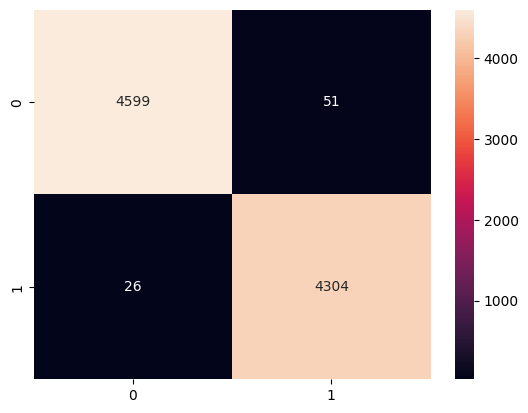

In [115]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_ir), annot=True, fmt='d')

<Axes: >

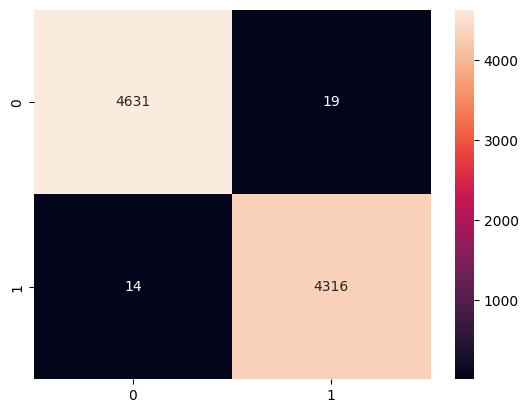

In [116]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')

<Axes: >

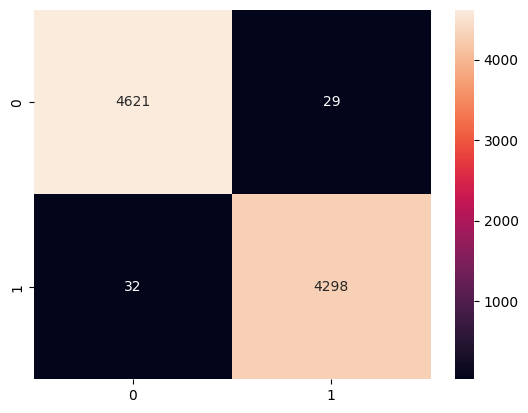

In [117]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')

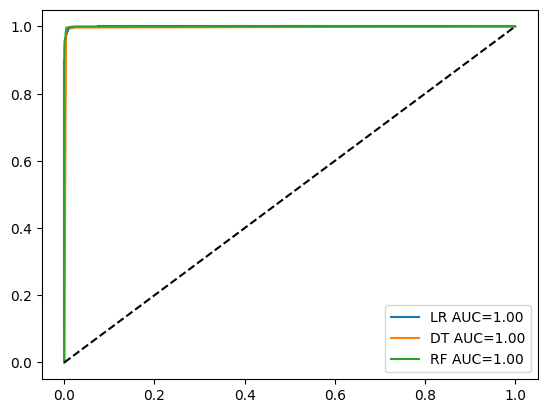

In [119]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:,1], pos_label='true')
fpr_dt, tpr_dt, _ = roc_curve(y_test, DT.predict_proba(X_test)[:,1], pos_label='true')
fpr_rf, tpr_rf, _ = roc_curve(y_test, RF.predict_proba(X_test)[:,1], pos_label='true')

plt.plot(fpr_lr, tpr_lr, label=f'LR AUC={auc(fpr_lr,tpr_lr):.2f}')
plt.plot(fpr_dt, tpr_dt, label=f'DT AUC={auc(fpr_dt,tpr_dt):.2f}')
plt.plot(fpr_rf, tpr_rf, label=f'RF AUC={auc(fpr_rf,tpr_rf):.2f}')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

In [122]:
def predict_news(headline):
    headline = headline.lower()
    headline = vectorizer.transform([headline])
    prediction = lr.predict(headline)
    return prediction[0]

predict_news("Trump claims election was stolen")

'fake'